# 02 · Baseline Klasik & Metrik Probabilistik

Sebelum memakai deep learning, kita perlu pembanding:
- **Seasonal Naive**: "minggu depan sama dengan minggu lalu", dengan interval dari residual historis.
- **ETS (Holt-Winters)**: model statistik klasik dengan interval Gaussian.
- **Oracle**: distribusi *sebenarnya* (hanya mungkin pada data simulasi), yaitu batas terbaik.

### Bagaimana menilai forecast probabilistik?
| Metrik | Arti | Ideal |
|---|---|---|
| **CRPS** | akurasi + kalibrasi sekaligus | sekecil mungkin |
| **Coverage 80%** | % nilai aktual yang masuk interval 80% | ≈ 80% |
| **Lebar 80%** | lebar interval (ketajaman) | sesempit mungkin *asal* coverage terpenuhi |

Model yang intervalnya sempit tapi coverage-nya 50% berarti **terlalu percaya diri**, dan itu berbahaya untuk manajemen risiko.

In [1]:
%matplotlib inline
import warnings; warnings.filterwarnings("ignore")
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
pd.set_option("display.precision", 3)
plt.rcParams["figure.dpi"] = 110

In [2]:
from fedprob import QUANTILES
from fedprob.data import get_scenario, simulate, build_all_clients
from fedprob.experiment import _oracle_preds
from fedprob.models import seasonal_naive_quantiles, ets_quantiles
from fedprob.metrics import evaluate, reliability
from fedprob.plots import plot_fan, plot_reliability

sim = simulate(get_scenario("normal"))
clients = build_all_clients(sim)

In [3]:
preds = {"seasonal_naive": [], "ets": [], "oracle": []}
for c in clients:
    preds["seasonal_naive"].append(seasonal_naive_quantiles(c))
    preds["ets"].append(ets_quantiles(sim, c))
    preds["oracle"].append(_oracle_preds(sim, c))

rows = [{"method": m, "bank": c.name, **evaluate(c.test.y, p)}
        for m, plist in preds.items() for c, p in zip(clients, plist)]
metrics = pd.DataFrame(rows)
metrics.groupby("method").mean(numeric_only=True)

,MAE,CRPS,Coverage50,Coverage80,Coverage90,Lebar80
method,,,,,,
ets,0.359,0.203,0.513,0.819,0.918,1.229
oracle,0.285,0.162,0.424,0.724,0.844,0.778
seasonal_naive,0.417,0.237,0.536,0.828,0.926,1.457


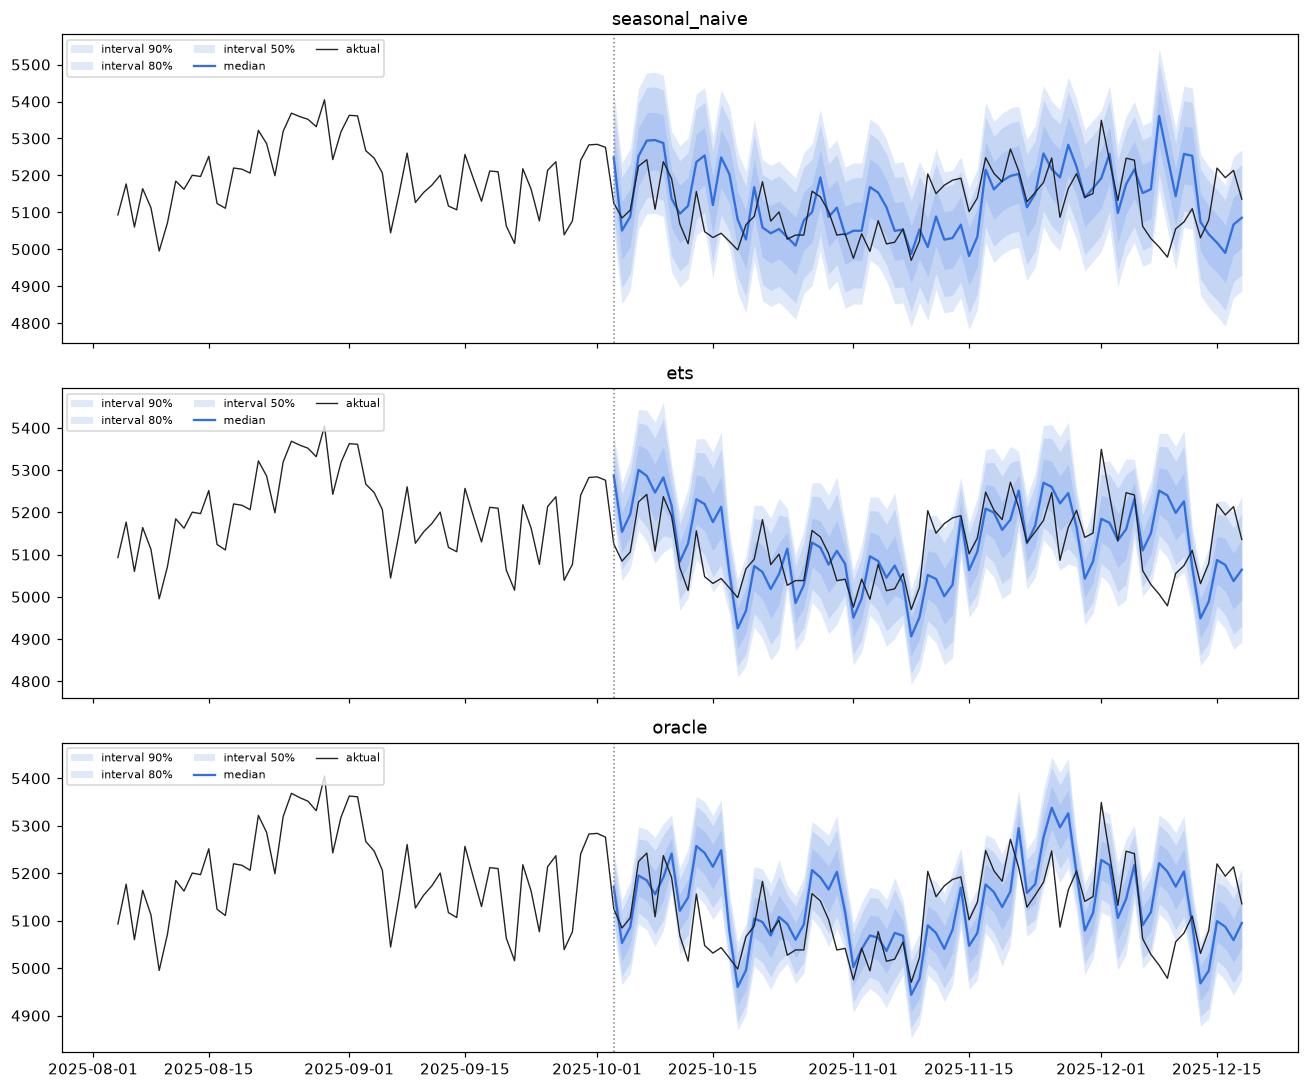

In [4]:
k = 0; c = clients[k]
fig, axes = plt.subplots(3, 1, figsize=(12, 10), sharex=True)
for ax, m in zip(axes, preds):
    plot_fan(sim, k, c.denorm(preds[m][k]), c.test.origins, ax=ax, title=m)
plt.tight_layout()

<Axes: title={'center': 'Kalibrasi'}, xlabel='kuantil nominal', ylabel='proporsi aktual <= prediksi'>

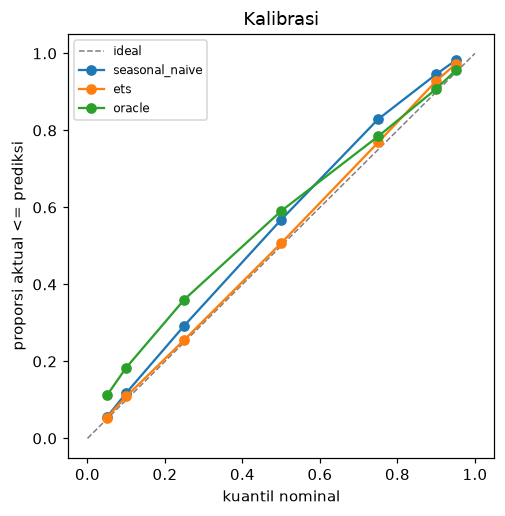

In [5]:
y = np.concatenate([c.test.y for c in clients])
plot_reliability({m: reliability(y, np.concatenate(p)) for m, p in preds.items()})

**Catatan penting tentang Oracle.** Oracle memakai distribusi *sebenarnya*, tetapi coverage 80%-nya
di periode uji ini hanya sekitar 72%. Mengapa? Periode uji hanya 90 hari, dan faktor pasar bersama
(AR(1), sangat persisten) membuat error semua bank dan semua horizon **saling berkorelasi**. Jadi
efektifnya kita hanya mengamati sedikit "kejadian" independen. Di unit test (`tests/test_core.py`)
yang memakai banyak periode acak, coverage Oracle tepat ~80%.

Pelajarannya: coverage yang diukur di periode pendek itu berisik. Karena itu kita membandingkan
model **terhadap Oracle**, bukan hanya terhadap angka nominal. Jarak antara baseline dan Oracle
adalah "ruang perbaikan" yang ingin kita kejar.